# Making the dataset and training the model

This file contains the code to make the dataset from depth tensor and the embeddings retrieved from the same tensors. But also one thing to keep track is 
error value of -1 for places where no depth values could be retriebed. They need to be filtered out and left out of the final training data. 

In [1]:
import argparse
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

In [2]:
from utils import getDevice

In [3]:
class EmbedDepthDataset(Dataset):
    """
    This class matched the YOLO embeddings from a file to depth retrieved
    for the same images and creates a dataset from them, that can be used to 
    train the final model.

    Args:
        embed_path: path to .pt embeddings (N,256)
        depths_path: path to .pt (N,)
    """

    def __init__(self, embed_path: str, depths_path: str):
        #opening the files
        embeds = torch.load(embed_path, weights_only=True).float()
        depths = torch.load(depths_path, weights_only=True).float()

        #filtering depths to only allow valid ones
        print(f"Removing {(depths==-1).sum()} invalid depths")
        mask = depths != -1
        embeds_masked = embeds[mask]
        depths_masked = depths[mask]   

        #saving results
        self.depths = depths_masked
        self.embeddings = embeds_masked

        assert len(self.embeddings)==len(self.depths), (
            f"The embeddings array is not the same length as the depths"
            f"EMBEDDINGS: {len(self.embeddings)}\nDEPTHS: {len(self.depths)}"
        )

    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.depths[idx]

In [ ]:
class DistanceRegressor(nn.Module):
    """
    Model to predict based on YOLO embeddings the distance to a car. It takes in (256) embedding and 
    outputs a single distance value in meters.

    Architecture is similar to the paper:
    1. Linear(256,128) + ReLU
    2. Linear(128,64) + ReLU
    3. Linear(64,1) + Softplus (to ensure positive output)
    """

    def __init__(self, input_size: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(512, 1),
            nn.Softplus()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [5]:
def run_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, loss_fn, device, train:bool):
    """
    Runs an epoch. Can be used for training and evaluation of the model.

    Args:
        model: the model to train/evaluate
        loader: dataloader for the dataset
        optimizer: optimizer to use for training (ignored if train=False)
        error_fn: loss function to use for error calculation
        device: device to run on (cpu or cuda)
        train: whether to run in training mode (True) or evaluation mode (False)
    """
    model.train() if train else model.eval()
    model_loss = 0

    #set modes according to train state
    with torch.set_grad_enabled(train):
        for embeds, depths in loader:
            #move inputs and target values to correct device
            embeds, depths = embeds.to(device), depths.to(device)

            #values are predicted and error calculation
            preds = model(embeds).squeeze()
            loss = loss_fn(preds, depths)
            model_loss += loss.item()

            #training step perforned here 
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
    return model_loss / len(loader)

def train_model(
        model: nn.Module, 
        dataset: Dataset, 
        optimizer: torch.optim.Optimizer, 
        loss_fn,
        device: torch.device, 
        epochs: int = 20, 
        batch_size: int = 64
    ):
    """
    Trains the model on the given dataset.

    Args:
        model: the model for training
        dataset: embeddings-depths pairs
        optimizer:optimizer to trains
        loss_fn: loss function to track progress
        device: string where to run the model
        epochs: number of epochs to run
        batch_size:
        learning_rate:
    """
    #we accumulate the losses 
    train_losses = np.array([])
    val_losses = np.array([])


    #split dataset into train and validation sets
    val_size = int(0.2 * len(dataset))
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    #create dataloaders for both sets
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    #training loop
    for epoch in range(epochs):
        train_loss = run_epoch(model, train_loader, optimizer, loss_fn, device, train=True)
        val_loss = run_epoch(model, val_loader, optimizer, loss_fn, device, train=False)
        #results are saved
        train_losses = np.append(train_losses, train_loss)
        val_losses = np.append(val_losses, val_loss)

        #progress printed
        if epoch % 10 == 0 or epoch == epochs-1:
            print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

In [6]:
EMBED_PATH = "../data/embeds_preds.pt"
DEPTHS_PATH = "../data/ransac_depth.pt"

dataset = EmbedDepthDataset(EMBED_PATH, DEPTHS_PATH)

# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss
model = DistanceRegressor()

# Create the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1.0)

epochs = 500

Removing 4 invalid depths


In [7]:
train_losses, val_losses = train_model(model, dataset, optimizer, loss_fn, getDevice(), epochs=epochs)

/home/tim/sidehustle/thesis/.venv/lib64/python3.12/site-packages/torch/xpu/__init__.py:60: UserWarning: XPU device count is zero! (Triggered internally at /pytorch/c10/xpu/XPUFunctions.cpp:115.)
  return torch._C._xpu_getDeviceCount()


Using device: cpu :3
Epoch 0/500 - Train Loss: 17.3778 - Val Loss: 17.1536
Epoch 10/500 - Train Loss: 6.2574 - Val Loss: 7.9050
Epoch 20/500 - Train Loss: 4.1599 - Val Loss: 5.4546
Epoch 30/500 - Train Loss: 3.9293 - Val Loss: 5.7066
Epoch 40/500 - Train Loss: 4.0935 - Val Loss: 4.2608
Epoch 50/500 - Train Loss: 3.6305 - Val Loss: 5.4414
Epoch 60/500 - Train Loss: 3.8595 - Val Loss: 4.4184
Epoch 70/500 - Train Loss: 3.7597 - Val Loss: 4.1737
Epoch 80/500 - Train Loss: 3.7807 - Val Loss: 4.3293
Epoch 90/500 - Train Loss: 3.5191 - Val Loss: 4.2061
Epoch 100/500 - Train Loss: 3.6445 - Val Loss: 3.6645
Epoch 110/500 - Train Loss: 3.8717 - Val Loss: 3.5227
Epoch 120/500 - Train Loss: 3.5690 - Val Loss: 4.4034
Epoch 130/500 - Train Loss: 3.2761 - Val Loss: 4.0145
Epoch 140/500 - Train Loss: 3.3599 - Val Loss: 4.1301
Epoch 150/500 - Train Loss: 3.3933 - Val Loss: 3.6214
Epoch 160/500 - Train Loss: 3.3383 - Val Loss: 4.1029
Epoch 170/500 - Train Loss: 3.3016 - Val Loss: 4.0808
Epoch 180/500 - 

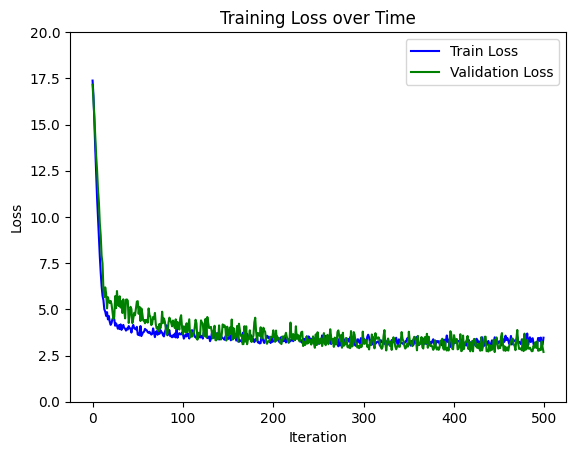

In [8]:
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="green")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.ylim(0, 20)
plt.title("Training Loss over Time")
plt.legend()    
plt.savefig("../visualizations/loss_plot.png")
plt.show()